**¿En que zonas hay mas temblores y porqué?**

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import skew, kurtosis, chi2_contingency

In [58]:
try:
    earthq = pd.read_csv("../datos/Earthquakes_South_Asia.csv")
    print(f"Se han leido los datos")
except:
    print("ERROR: No se leyeron los datos")
    

Se han leido los datos


In [59]:
pd.set_option("display.max_columns", None) # Visualizar todas las columnas
earthq.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1904-08-30T11:43:20.850Z,30.684,100.608,15.0,7.09,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957826,2022-04-25T20:23:00.657Z,"150 km WNW of Kangding, China",earthquake,NaN,25.0,0.40,NaN,reviewed,iscgem,iscgem
1,1905-02-17T11:41:07.820Z,23.689,97.170,15.0,7.26,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957836,2022-04-25T20:23:21.748Z,"62 km S of Bhamo, Myanmar",earthquake,NaN,25.0,0.37,NaN,reviewed,iscgem,iscgem
2,1905-04-04T00:49:59.230Z,32.597,76.916,20.0,7.90,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957848,2022-04-25T20:23:47.590Z,"10 km WNW of Kyelang, India",earthquake,NaN,25.0,0.40,NaN,reviewed,iscgem,iscgem
3,1905-05-31T18:23:32.750Z,18.895,120.203,15.0,6.80,mw,NaN,NaN,NaN,NaN,iscgem,iscgem610548604,2022-04-25T20:39:25.950Z,"61 km NW of Davila, Philippines",earthquake,NaN,5.0,0.46,NaN,reviewed,iscgem,iscgem
4,1905-06-02T05:39:39.600Z,33.715,131.759,60.0,6.91,mw,NaN,NaN,NaN,NaN,iscgem,iscgem16957852,2022-04-25T20:23:58.797Z,"31 km SSW of Hikari, Japan",earthquake,NaN,15.4,0.53,NaN,reviewed,iscgem,iscgem


In [60]:
earthq.tail()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
102129,2024-11-13T05:13:20.699Z,36.5438,71.1536,220.721,5.1,mb,55.0,62.0,2.218,0.65,us,us7000nrhn,2024-11-14T09:53:39.278Z,"37 km WSW of Ashkāsham, Afghanistan",earthquake,8.02,9.774,0.074,59.0,reviewed,us,us
102130,2024-11-13T10:06:21.861Z,36.5278,71.2041,125.016,4.1,mb,17.0,188.0,2.256,1.03,us,us7000nril,2024-11-13T10:23:40.040Z,"34 km WSW of Ashkāsham, Afghanistan",earthquake,10.62,13.905,0.234,5.0,reviewed,us,us
102131,2024-11-13T15:47:56.709Z,36.5196,70.8494,224.206,4.9,mb,88.0,65.0,2.086,0.63,us,us7000nrj9,2024-11-13T17:21:31.226Z,"38 km S of Jurm, Afghanistan",earthquake,7.40,6.859,0.044,163.0,reviewed,us,us
102132,2024-11-14T02:12:06.138Z,29.1797,130.1280,60.094,4.5,mb,32.0,101.0,2.339,0.85,us,us7000nrn4,2024-11-14T02:36:05.040Z,"95 km NNE of Tatsugō, Japan",earthquake,3.78,9.823,0.121,20.0,reviewed,us,us
102133,2024-11-14T02:38:16.141Z,23.8706,121.6613,25.715,4.6,mwr,90.0,54.0,0.582,0.85,us,us7000nrn9,2024-11-14T03:48:34.730Z,"13 km SSE of Hualien City, Taiwan",earthquake,3.19,5.012,0.073,18.0,reviewed,us,us


In [61]:
earthq.nunique()

time               102134
latitude            57497
longitude           56801
depth               16571
mag                   289
magType                13
nst                   544
gap                  2599
dmin                 7641
rms                   191
net                     5
id                 102134
updated             86118
place               59381
type                    3
horizontalError      1394
depthError           4437
magError              413
magNst                313
status                  2
locationSource         14
magSource              24
dtype: int64

In [62]:
earthq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102134 entries, 0 to 102133
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   time             102134 non-null  object 
 1   latitude         102134 non-null  float64
 2   longitude        102134 non-null  float64
 3   depth            102134 non-null  float64
 4   mag              102134 non-null  float64
 5   magType          102134 non-null  object 
 6   nst              44321 non-null   float64
 7   gap              61683 non-null   float64
 8   dmin             30173 non-null   float64
 9   rms              92654 non-null   float64
 10  net              102134 non-null  object 
 11  id               102134 non-null  object 
 12  updated          102134 non-null  object 
 13  place            102134 non-null  object 
 14  type             102134 non-null  object 
 15  horizontalError  27423 non-null   float64
 16  depthError       55742 non-null   floa

In [63]:
earthq.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,102134.000000,102134.000000,102134.000000,102134.000000,44321.000000,61683.000000,30173.000000,92654.000000,27423.000000,55742.000000,33222.000000,84644.000000
mean,18.449853,106.247929,59.483604,4.560348,46.302498,112.036942,2.795344,0.908260,7.883577,9.071499,0.141041,18.759569
std,13.615392,21.880469,77.597673,0.540563,61.412490,48.965703,3.103738,0.273452,2.792829,8.599259,0.090126,28.648616
min,0.000000,60.001000,0.000000,3.000000,3.000000,9.000000,0.001000,0.000000,0.810000,0.000000,0.000000,1.000000
25%,5.162625,91.839100,19.120750,4.200000,15.000000,76.100000,1.117000,0.720000,6.100000,3.600000,0.083000,4.000000
50%,17.420150,120.365500,33.000000,4.500000,26.000000,107.400000,1.968000,0.900000,7.630000,7.000000,0.123000,10.000000
75%,30.714675,126.158000,64.300000,4.800000,51.000000,141.000000,3.221000,1.100000,9.500000,11.000000,0.173000,21.000000
max,45.000000,134.998000,678.000000,9.100000,776.000000,337.800000,56.265000,2.220000,31.700000,74.900000,1.840000,941.000000


<h1 align="center">Analisis Univariado</h1>


In [64]:
# Obtenemos las variables numericas y categoricas por separado
col_num = earthq.select_dtypes(include=["Float64"])
col_cat = earthq.select_dtypes(include=["object"])

print(f"\tVariables numericas:\n{col_num.columns}")
print(f"\n\tVariables categoricas:\n{col_cat.columns}")

num = col_num[["latitude", "longitude", "depth", "mag", "rms"]]
cat = col_cat[["time","magType", "type", "status"]]

print(f"\n\tNos quedaremos con las siguientes:")
print(f"\nVariables numericas:\n{num.columns}")
print(f"\nVariables categoricas:\n{cat.columns}")

	Variables numericas:
Index(['latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms',
       'horizontalError', 'depthError', 'magError', 'magNst'],
      dtype='object')

	Variables categoricas:
Index(['time', 'magType', 'net', 'id', 'updated', 'place', 'type', 'status',
       'locationSource', 'magSource'],
      dtype='object')

	Nos quedaremos con las siguientes:

Variables numericas:
Index(['latitude', 'longitude', 'depth', 'mag', 'rms'], dtype='object')

Variables categoricas:
Index(['time', 'magType', 'type', 'status'], dtype='object')


#### Un análisis a las variables numéricas seleccionadas

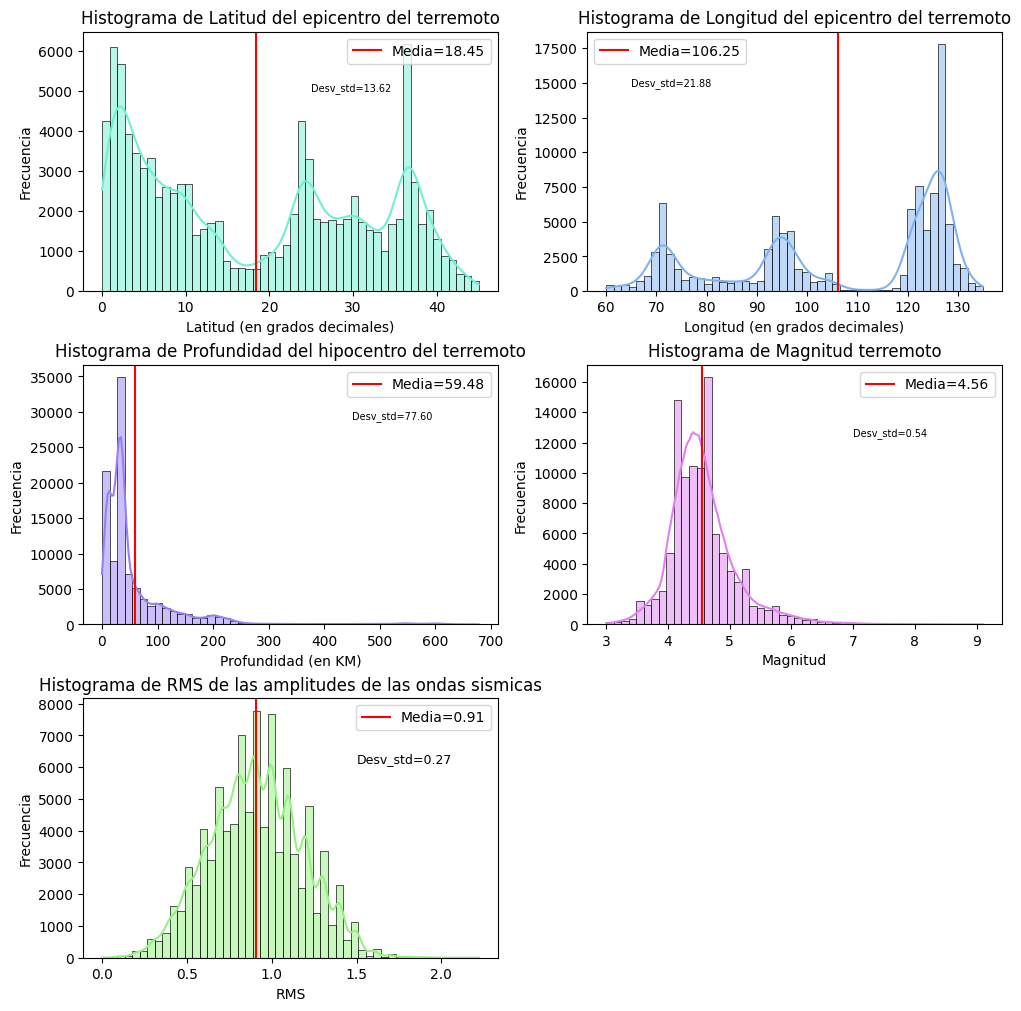

In [65]:
fig, axes = plt.subplots(3,2, figsize=(10,10), constrained_layout=True)
axes = axes.flatten()# convierte matriz 2x3 a una lista de 6

ax1, ax2, ax3, ax4, ax5, ax6 = axes
fig.delaxes(ax6)# eliminar el sexto
sns.histplot(data = num, x ="latitude", ax = ax1, color="#6EF0D2", bins=50, kde=True)
ax1.set_title("Histograma de Latitud del epicentro del terremoto")
ax1.set_xlabel("Latitud (en grados decimales)")
ax1.set_ylabel("Frecuencia")

mean_lat = num["latitude"].mean()
desv_std_lat = num["latitude"].std()
ax1.axvline(x=mean_lat, color="red", label=f"Media={mean_lat:.2f}")
ax1.text(25,5000,f"Desv_std={desv_std_lat:.2f}", fontsize = 7)
ax1.legend()


sns.histplot(data=num, x="longitude", ax = ax2, color="#80B2F2", bins=50, kde=True)
ax2.set_title("Histograma de Longitud del epicentro del terremoto")
ax2.set_xlabel("Longitud (en grados decimales)")
ax2.set_ylabel("Frecuencia")

mean_lon = num["longitude"].mean()
desv_std_lon = num["longitude"].std()
ax2.axvline(x=mean_lon, color="red", label=f"Media={mean_lon:.2f}")
ax2.text(65,14800,f"Desv_std={desv_std_lon:.2f}", fontsize = 7)
ax2.legend()

sns.histplot(data=num, x="depth", ax = ax3, color="#9780F2", bins=50, kde=True)
ax3.set_title("Histograma de Profundidad del hipocentro del terremoto")
ax3.set_xlabel("Profundidad (en KM)")
ax3.set_ylabel("Frecuencia")

mean_depth = num["depth"].mean()
desv_std_depth = num["depth"].std()
ax3.axvline(x=mean_depth, color="red", label=f"Media={mean_depth:.2f}")
ax3.text(450,29000,f"Desv_std={desv_std_depth:.2f}", fontsize = 7)
ax3.legend()

sns.histplot(data=num, x="mag", ax = ax4, color="#E180F2", bins=50, kde=True)
ax4.set_title("Histograma de Magnitud terremoto")
ax4.set_xlabel("Magnitud")
ax4.set_ylabel("Frecuencia")

mean_mag = num["mag"].mean()
desv_std_mag = num["mag"].std()
ax4.axvline(x=mean_mag, color="red", label=f"Media={mean_mag:.2f}")
ax4.text(7,12500,f"Desv_std={desv_std_mag:.2f}", fontsize = 7)
ax4.legend()


sns.histplot(data=num, x="rms", ax = ax5, color="#95F280", bins=50, kde=True)
ax5.set_title("Histograma de RMS de las amplitudes de las ondas sismicas")
ax5.set_xlabel("RMS")
ax5.set_ylabel("Frecuencia")


mean_rms = num["rms"].mean()
desv_std_rms = num["rms"].std()
ax5.axvline(x=mean_rms, color="red", label=f"Media={mean_rms:.2f}")
ax5.text(1.5,6150,f"Desv_std={desv_std_rms:.2f}", fontsize = 9)
ax5.legend()

plt.show()

**Latitud:** Sus observaciones no tienen una distribución identificable, se observan tres picos de los cuales dos de estos son practicamente iguales, probablemente hagan referencia a regiones con ciertas similitudes, sus colas no son muy pesadas, la media está en medio de los dos picos destacables, aunque la media en este tipo de distribuciones no es muy representativa, su desviación estandar no es relativamente grande, es probable que no tenga datos atípicos

**Longitud:** Se observa un pico que destaca por encima de los otros dos, podemos pensar que hay una concentración da muestras de terremotos cuyo epicentro tiene asociado una longitud que corresponde a esos picos. Su media guarda distancias no muy diferentes entre los picos de los extremos, se deberia realizar un analisis de atípicos para estar más seguros del comportamiento aqui.

**Profundidad:** La mayoria de terremotos tienen un hipocentro de entre 0 y aproximadamente 50 km de profundidad, además se observa una cola positiva bastante pesada, aqui es posible que visualicemos más atípicos que con los dos anteriores factores.

**Magnitud:** Se observa lo esperado, la mayoria de terremotos estan alrededor de 4 y 5, es poco común medir un sismo menor a esto y es aun más raro que un terremoto supere este umbral. Sus muestras no están muy lejanas de la media y su desviacion estandar no es muy grande, se cree que no habrán muchos outliers.

**RMS:** Magnitud promedio de la amplitud de las ondas sísmicas. Nos habla de la "intensidad" de las ondas sismicas, que son proporcionales a la potencia promedio, en este caso vemos casi un comportamiento normal centrada cerca de 0.9, la mayoria de terremotos tienen una magnitud promedio de la amplitud de sus ondas sismicas entre 0.75 y 1.25 aproximadamente (en las unidades medidas por los sensores). Además se pueden observas colas no muy pesadas, quizas se necesite de un analisis de atípicos para esta caracteristica, aqui las muestras vuelven a estar cerca de la media y su desviación estandar lo reafirma.

In [66]:
def compute_skew_kurtosis(df):
    result = {}
    for col in df.columns:
        sk = skew(df[col], nan_policy="omit") # ignoremos los nan
        kurt = kurtosis(df[col],nan_policy="omit", fisher=True)
        result[col] = {f"Asimetria": sk, f"Kurtosis" : kurt}
    return pd.DataFrame(result).T# traspuesta para poner las filas (que queremos que sean las columnas) en las columnas

In [67]:
table_sk_kurt = compute_skew_kurtosis(num)
print(table_sk_kurt)

           Asimetria   Kurtosis
latitude    0.178827  -1.449473
longitude  -0.506774  -1.263838
depth       3.774295  18.947325
mag         1.208647   3.549066
rms         0.063137  -0.248188


|       | Asimetria                                                                       | Kurtosis                        |
|-------|---------------------------------------------------------------------------------|---------------------------------|
|Latitud|Sesgo positivo (Datos mayormente ubicados a la izquierda con respecto a la media) aunque para esta caracteristica no es un valor de asimetria muy grande|Colas muy ligeras, pocos atípicos|
|Longitud|Sesgo negativo (Datos mayormente ubicados a la derecha con respecto a la media)|Colas muy ligeras, pocos atípicos|
|Profundidad|Sesgo positivo, en esta si se evidencia que hay bastantes mas datos ubicados a la izquierda con respecto a la media|Colas muy pesadas, muchos atípicos|
|Magnitud|Sesgo positivo, unos cuantas observaciones que muestran mayoria de datos a la izquierda de la media|Colas pesadas, varios atípicos|
|RMS|Sesgo positivo, pero muy poco, practicamente los datos estan todos cerca de la media|Colas muy ligeras, no hay casi outliers|

En cuanto a latitud y longitud, se osbervan estos sesgos y promedios debido a que son muestras de unicamente del sur de Asia, por lo que datos atípicos probablemente representen coordenadas fuera de esta región del continente y es posible que sean por error al ingresarlos

Analizando a la profundidad, se puede decir que la mayoria de terremotos son superficiales o casi superficiales.

La magnitud cuenta que la mayoria de terremotos, según su magnitud son ligeros (3.0-3.9) o moderados (4.0-4.9)

Para el RMS dice que en promedio, entre sismos, provocan movimientos de suelo bastante uniformes y es pocó común encontrar casos donde la superficie afectada por el terremoto se mueva extremadamente fuerte a comparación de la media, es decir, casi siempre el suelo vibra de manera similar.

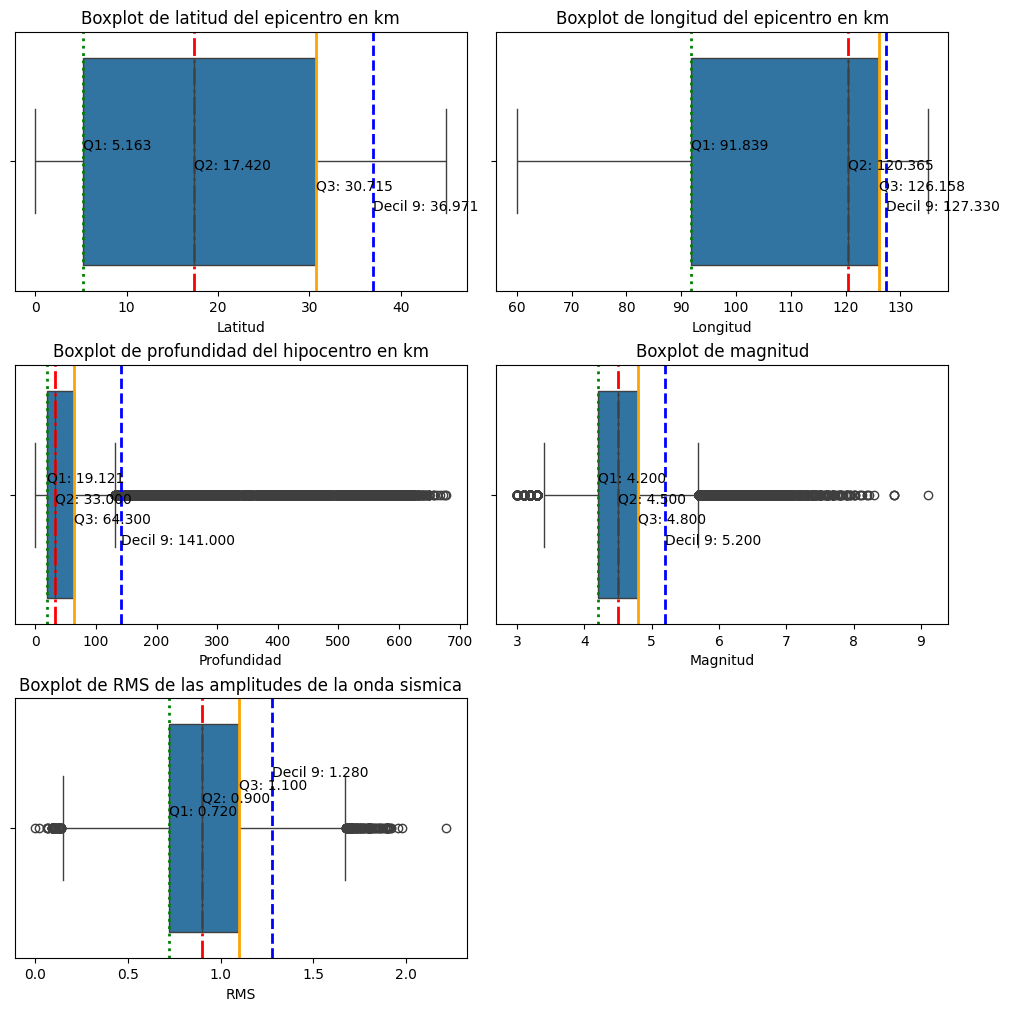

In [68]:
styles = [":", "-.", "-", "--"]
labels = ["Q1","Q2","Q3","Decil 9"]
color = ["green", "red", "orange", "blue"]
percentiles = []
fig, axes = plt.subplots(3,2, figsize=(10,10), constrained_layout=True)
axes = axes.flatten()
ax1, ax2, ax3, ax4, ax5, ax6 = axes
fig.delaxes(ax6)
for i in range(25,76,25):
    percentiles.append(np.percentile(num["latitude"], i))
percentiles.append(np.percentile(num["latitude"], 90))
sns.boxplot(data=num, x = "latitude", ax=ax1)
ax1.set_title("Boxplot de latitud del epicentro en km")
for i in range(len(percentiles)):
    ax1.axvline(x = percentiles[i], color=color[i], linestyle=styles[i], linewidth=2, label=labels[i])
ax1.set_xlabel("Latitud")
for i in range(len(percentiles)):
    ax1.text(percentiles[i],-0.05 + plt.ylim()[1]*0.4*i/5,f"{labels[i]}: {percentiles[i]:.3f}")

percentiles = []
for i in range(25,76,25):
    percentiles.append(np.percentile(num["longitude"], i))
percentiles.append(np.percentile(num["longitude"], 90))
sns.boxplot(data=num, x = "longitude", ax=ax2)
ax2.set_title("Boxplot de longitud del epicentro en km")
for i in range(len(percentiles)):
    ax2.axvline(x = percentiles[i], color=color[i], linestyle=styles[i], linewidth=2, label=labels[i])
ax2.set_xlabel("Longitud")
for i in range(len(percentiles)):
    ax2.text(percentiles[i],-0.05 + plt.ylim()[1]*0.4*i/5,f"{labels[i]}: {percentiles[i]:.3f}")

percentiles = []
for i in range(25,76,25):
    percentiles.append(np.percentile(num["depth"], i))
percentiles.append(np.percentile(num["depth"], 90))
sns.boxplot(data=num, x = "depth", ax=ax3)
ax3.set_title("Boxplot de profundidad del hipocentro en km")
for i in range(len(percentiles)):
    ax3.axvline(x = percentiles[i], color=color[i], linestyle=styles[i], linewidth=2, label=labels[i])
ax3.set_xlabel("Profundidad")
for i in range(len(percentiles)):
    ax3.text(percentiles[i],-0.05 + plt.ylim()[1]*0.4*i/5,f"{labels[i]}: {percentiles[i]:.3f}")

percentiles = []
for i in range(25,76,25):
    percentiles.append(np.percentile(num["mag"], i))
percentiles.append(np.percentile(num["mag"], 90))
sns.boxplot(data=num, x = "mag", ax=ax4)
ax4.set_title("Boxplot de magnitud")
for i in range(len(percentiles)):
    ax4.axvline(x = percentiles[i], color=color[i], linestyle=styles[i], linewidth=2, label=labels[i])
ax4.set_xlabel("Magnitud")
for i in range(len(percentiles)):
    ax4.text(percentiles[i],-0.05 + plt.ylim()[1]*0.4*i/5,f"{labels[i]}: {percentiles[i]:.3f}")

percentiles = []
for i in range(25,76,25):
    percentiles.append(np.nanpercentile(num["rms"], i))
percentiles.append(np.nanpercentile(num["rms"], 90))
sns.boxplot(data=num, x = "rms", ax=ax5)
ax5.set_title("Boxplot de RMS de las amplitudes de la onda sismica")
for i in range(len(percentiles)):
    ax5.axvline(x = percentiles[i], color=color[i], linestyle=styles[i], linewidth=2, label=labels[i])
ax5.set_xlabel("RMS")
for i in range(len(percentiles)):
    ax5.text(percentiles[i],-0.05 + plt.ylim()[1]*0.5*i/5,f"{labels[i]}: {percentiles[i]:.3f}")

plt.show()

Las suposiciones anteriores en las Kurtosis se cumplen, basicamente no hay atípicos para longitud ni latitud, para rms hay datos con menos desviación que la magnitud y esta ultima se observa claramente menor cantidad de outliers a comparación con la profundidad

#### Un análisis a las variables categóricas seleccionadas

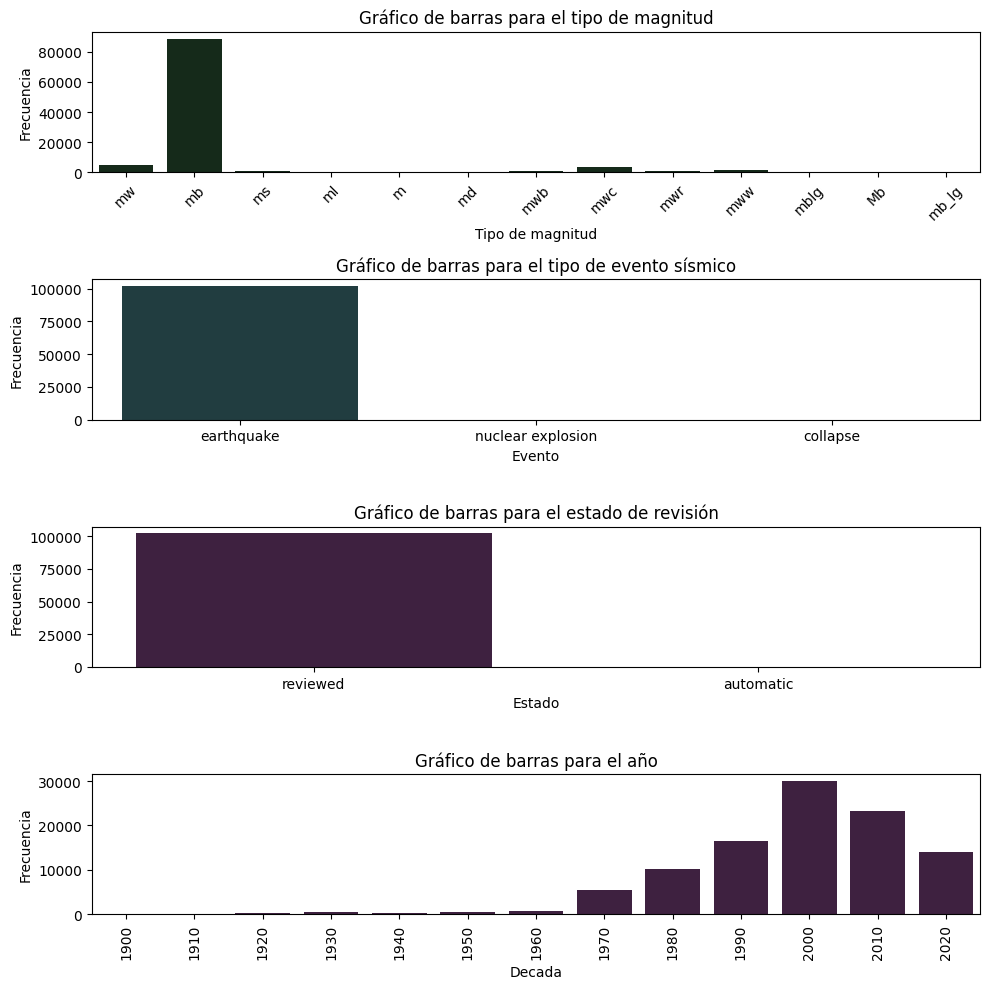

In [69]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(4,1, figsize=(10,10))

sns.countplot(data=cat, x = "magType", ax=ax1, color="#112E18")
ax1.set_title("Gráfico de barras para el tipo de magnitud")
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel("Frecuencia")
ax1.set_xlabel("Tipo de magnitud")

sns.countplot(data=cat, x = "type", ax=ax2, color="#1C4145")
ax2.set_title("Gráfico de barras para el tipo de evento sísmico")
ax2.set_ylabel("Frecuencia")
ax2.set_xlabel("Evento")

sns.countplot(data=cat, x = "status", ax=ax3, color="#421C45")
ax3.set_title("Gráfico de barras para el estado de revisión")
ax3.set_ylabel("Frecuencia")
ax3.set_xlabel("Estado")

sns.countplot(data=cat, x = (pd.to_datetime(cat["time"]).dt.year // 10 * 10).sort_index(), ax=ax4, color="#421C45")
ax4.set_title("Gráfico de barras para el año")
ax4.set_ylabel("Frecuencia")
ax4.tick_params(axis='x', rotation=90)
ax4.set_xlabel("Decada")

plt.tight_layout()
plt.show()

In [70]:
for i in cat.columns[1:]:
    print(cat[i].value_counts())
    print()

magType
mb       88844
mw        4671
mwc       3596
mww       1832
mwr       1007
ms         663
mwb        578
ml         499
m          427
md           6
mblg         6
mb_lg        3
Mb           2
Name: count, dtype: int64

type
earthquake           102101
nuclear explosion        32
collapse                  1
Name: count, dtype: int64

status
reviewed     102129
automatic         5
Name: count, dtype: int64



In [96]:
decadas = (pd.to_datetime(cat["time"]).dt.year//10* 10).value_counts().sort_index()
decadas_df = (pd.to_datetime(cat["time"]).dt.year//10* 10).sort_index()
decadas_df = pd.DataFrame(decadas_df)
decadas

time
1900       61
1910      163
1920      395
1930      599
1940      357
1950      486
1960      760
1970     5398
1980    10108
1990    16424
2000    30096
2010    23334
2020    13953
Name: count, dtype: int64

**¿Qué podemos decir de lo anterior?**

Para tipo de magnitud:
- La gran mayoria de observaciones son detectadas mediante magnitudes mb (Magnitud de onda corporal). Es una unidad de medida del tamaño de un sismo basada en la amplitu de las ondas de cuerpo, como las ondas P con un periodo de 1 segundo. Su desventaja radica en que con sismos de gran magnitud deja de ser tan preciso.
- Seguido de mb, vienen las mw, que se refiere a magnitud de momento sísmico, mwc que habla de magnitud de centroide sísmico y mww hace referencia a la magnitud del momento obtenida de la fase W (un tipo de onda que se caracteriza por su longitud de onda grande que viajan en el interior de la tierra). Todas estas miden cantidad de energía liberada por el sismo.
- Hay varias categorias de esta variable "tipo de magnitud" que se refieren a lo mismo como mw, mwc, mww, mwr y mwb, igualmente para m, md y mc, tambien parace que hay subcategorias que son exactamente lo mismo pero su escritura es distinta, como el caso de "mb" y "Mb" que son el mismo método solo que escrito de otra forma y pasa igual con "mblg" y "mb_lg". Se podria considerar el juntar estas variables.

Para el tipo de evento:
- El dataset no solo habla de terremotos en si, sino de vibraciones detectadas en el sur de Asia, por lo que detecta colapsos subterraneos (debido a construcciones o demoliciones), explociones nucleares (como pruebas miltares) y terremotos
- La mayoria de observaciones corresponden a terremotos o sismos, las demas podrian ser despreciables (no representan mas del 0.0323% de los datos en total).

Para el estado de revisión:
- La gran mayoria de detecciones sismicas fueron tomadas automaticamente por el sistema, unicamente 5 fueron tomadas, analizadas y corregidas por un humano, eso corresponde a menos del 0.0049% de las observaciones.

Para time (en este caso, decadas):
- A partir de la decada de los 70s hasta la actualidad es que tenemos la gran mayoria de observaciones y son quienes nos darán mas información para realizar un analisis.


<h1 align="center">Analisis Bivariado y Multivariado</h1>
<h3 align="center">Y detección de outliers</h3>

#### Matriz de correlación entre variables númericas

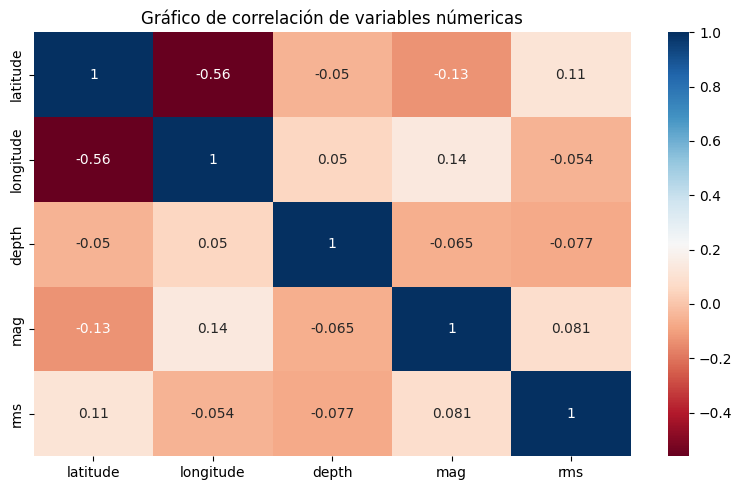

In [72]:
corr = num.corr() # matriz de correlacion
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="RdBu")
plt.title("Gráfico de correlación de variables númericas")
plt.tight_layout()
plt.show()


Las variables númericas seleccionadas no están muy relacionadas, a excepción de longitud y latitud, aunque ya estudiamos que esta relación es debido a la región en la que fueron tomados los datos (Sur de Asia), a pesar de esto, no es muy fuerte la correlación entre estas.

Al ver relaciones tan bajas, nos dice que cada variable nos brinda información distinta, lo cual alimentará el análisis y algún modelo de machine learning (si se plantea realizarlo).

#### Gráfico de correlacion (gráfico de dispersión) entre 3 variables

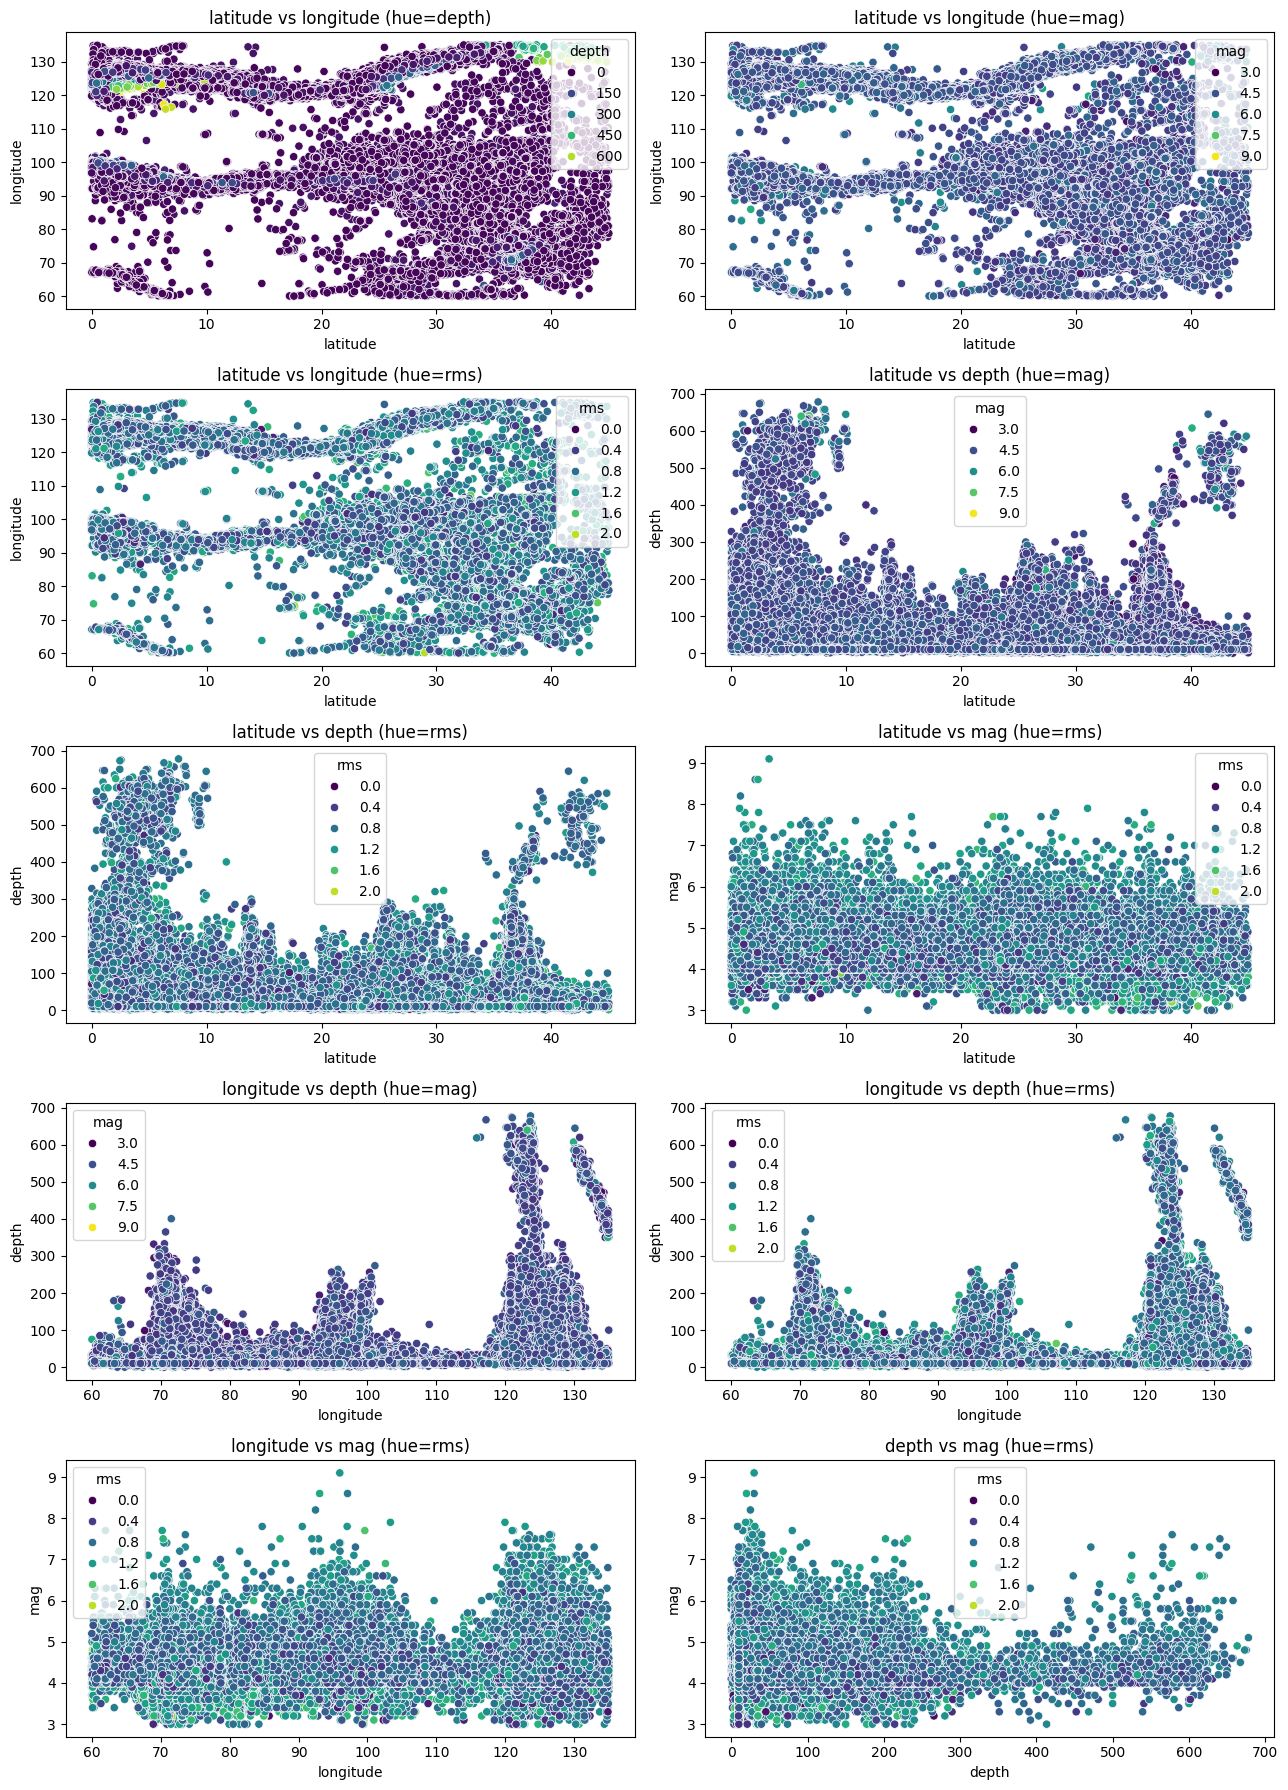

In [73]:
fig, axes = plt.subplots(5, 2, figsize=(13,18))
count_2 = 0
axes = axes.flatten()

for i in range(5):
    for j in range(i+1,5):
        for k in range(j+1,5):
            if count_2 >= len(axes):
                break # se detiene si ya están los 10 graficos
            sns.scatterplot(x = num[num.columns[i]], y = num[num.columns[j]], hue=num[num.columns[k]],palette="viridis", ax=axes[count_2], legend="brief")
            axes[count_2].set_title(f"{num.columns[i]} vs {num.columns[j]} (hue={num.columns[k]})")
            count_2 +=1
plt.tight_layout()
plt.show()

No parecen haber relaciones lineales ni polinomiales entre las variables numericas y como lo vimos en la matriz de correlación, no hay practicamente correlación entre ellas

In [74]:
for i in range(len(cat.columns)):
    for j in range(i+1, len(cat.columns)):
        if j >= len(cat.columns):
            break
        print(f"Variables: {cat.columns[i]} vs {cat.columns[j]}")
        tab_indep = pd.crosstab(cat[cat.columns[i]], cat[cat.columns[j]])
        chi2, p, dof, expected = chi2_contingency(tab_indep)
        print(f"Chi cuadrado = {chi2}\nValor p = {p}\nGrados de libertad {dof}")
        print()

Variables: time vs magType
Chi cuadrado = 1225608.0
Valor p = 0.4967724153295638
Grados de libertad 1225596

Variables: time vs type
Chi cuadrado = 204268.0
Valor p = 0.49833557828947017
Grados de libertad 204266

Variables: time vs status
Chi cuadrado = 102134.00000000009
Valor p = 0.4985288434876008
Grados de libertad 102133

Variables: magType vs type
Chi cuadrado = 208.467040344453
Valor p = 2.381123203412274e-31
Grados de libertad 24

Variables: magType vs status
Chi cuadrado = 90.26429266800271
Valor p = 4.3885726630246974e-14
Grados de libertad 12

Variables: type vs status
Chi cuadrado = 0.0016161259734868024
Valor p = 0.9991922634082301
Grados de libertad 2



- **time vs magType:** p>0.05 -> No hay evidencia para afirmar que las variables están relacionadas (hay independencia)
- **time vs type:** p>0.05 -> No hay evidencia para afirmar que las variables están relacionadas (hay independencia)
- **time vs status:** p>0.05 -> No hay evidencia para afirmar que las variables están relacionadas (hay independencia)
- **magType vs type:** p<<0.05 -> Las variables están relacionadas (muy relacionadas), no hay independencia
- **magType vs status:** p<<0.05 -> Las variables están relacionadas (muy relacionadas), no hay independencia
- **type vs status:** p>0.05 -> No hay evidencia para afirmar que las variables están relacionadas (hay independencia)

Se observa gran cantidad de grados de libertad para la variable time, asi que reagrupandola por decadas para asi obtener un valor p que nos brinde mas precisión, se obtiene lo siguiente:


In [99]:
for i in range(1, len(cat.columns)):
    if i >= len(cat.columns):
        break
    print(f"Variables: {decadas_df.columns[0]} vs {cat.columns[i]}")
    tab_indep = pd.crosstab(decadas_df["time"], cat[cat.columns[i]])
    chi2, p, dof, expected = chi2_contingency(tab_indep)
    print(f"Chi cuadrado = {chi2}\nValor p = {p}\nGrados de libertad {dof}")
    print()

Variables: time vs magType
Chi cuadrado = 73895.98459984272
Valor p = 0.0
Grados de libertad 144

Variables: time vs type
Chi cuadrado = 48.95892272675177
Valor p = 0.0019168559086679869
Grados de libertad 24

Variables: time vs status
Chi cuadrado = 41.866513747925296
Valor p = 3.5072242434388644e-05
Grados de libertad 12



Con esto, la conclusión final es:
- **time vs magType:** p<0.05 -> Las variables están relacionadas, no hay independencia
- **time vs type:** p<0.05 -> Las variables están relacionadas, no hay independencia
- **time vs status:** p<0.05 -> Las variables están relacionadas, no hay independencia
- **magType vs type:** p<<0.05 -> Las variables están relacionadas (muy relacionadas), no hay independencia
- **magType vs status:** p<<0.05 -> Las variables están relacionadas (muy relacionadas), no hay independencia
- **type vs status:** p>0.05 -> No hay evidencia para afirmar que las variables están relacionadas (hay independencia)


Ahora se observa que estas variables estan relacionadas en su gran mayoria, aún asi, tener en cuenta que la variable time ha sido reducida en este analisís, anteriormente vimos como si habia dependencia, por lo que se recomienda seguir estudiando esta variable junto con magType, type y status